# Notebook 04: Stochastic Forecasting, MBC, and Life Expectancy

## Overview
This notebook generates stochastic longevity projections for the 6-country frontier cluster from 2020 to 2050, using the AINN champion model trained in Notebook 03. It produces sex-specific projections (Male and Female separately) and assesses the contribution of Mean-Bias Correction (MBC) as a credibility-weighting mechanism.

## Objectives
1. **Recursive MC Dropout Forecasting**: Generate 1,000 stochastic trajectories of $\Delta K_t$ (Male and Female) for 2021-2050.
2. **Dual Uncertainty**: Combine MC Dropout (model uncertainty) with Li-Lee calibrated process noise (process uncertainty).
3. **Level Reconstruction**: Integrate first-difference forecasts back to $K_t$ levels.
4. **MBC Analysis**: Compare AINN with and without Mean-Bias Correction; formalise MBC as Bayesian shrinkage.
5. **Life Expectancy ($e_0$)**: Reconstruct stochastic mortality surfaces and compute $e_0$ trajectories for all 6 countries × 2 sexes.
6. **Persistence**: Save all stochastic results for downstream analysis (Notebook 05).


## 4.1: Setup & Asset Loading

In [1]:
import sys
sys.path.append('../src')
from reproducibility import set_seed
set_seed(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, logging, warnings
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)
from tensorflow import keras
from tensorflow.keras import layers
import joblib

from style_config import set_style, save_dual, COUNTRIES, COUNTRY_COLORS
set_style("notebook")

PROCESSED_DIR = "../data/processed/"
MODELS_DIR = "../models/"
FIGURES_DIR = "../reports/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load champion model and scaler
champion_model = keras.models.load_model(
    os.path.join(MODELS_DIR, "ainn_champion.keras"),
    compile=False
)
scaler = joblib.load(os.path.join(MODELS_DIR, "scaler_joint.pkl"))

# Load training metadata
with open(os.path.join(PROCESSED_DIR, "training_meta.pkl"), "rb") as f:
    meta = pickle.load(f)

LOOKBACK = meta["lookback"]
N_FEATURES = meta["n_features"]
TRAIN_SPLIT_IDX = meta["train_split_idx"]

# Load Li-Lee parameters
with open(os.path.join(PROCESSED_DIR, "li_lee_params.pkl"), "rb") as f:
    bundle = pickle.load(f)

feature_matrices = bundle["feature_matrices"]
common_factors = bundle["common_factors"]
specific_factors = bundle["specific_factors"]
YEARS = bundle["metadata"]["years"]
AGES = bundle["metadata"]["ages"]
N_AGES = len(AGES)

print(f"Champion model loaded: lookback={LOOKBACK}, features={N_FEATURES}")
print(f"Architecture: {[l.name for l in champion_model.layers]}")
print(f"\nLi-Lee parameters loaded.")
print(f"Years: {YEARS[0]}-{YEARS[-1]}, Ages: {AGES[0]}-{AGES[-1]}")
print(f"Cluster: {list(COUNTRIES.keys())}")


/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Champion model loaded: lookback=15, features=8
Architecture: ['input_layer_100', 'lstm_200', 'dropout_200', 'lstm_201', 'dropout_201', 'dense_100']

Li-Lee parameters loaded.
Years: 1956-2020, Ages: 0-90
Cluster: ['CHE', 'SWE', 'NOR', 'DEUTW', 'NLD', 'JPN']


## 4.2: Prepare Input Sequences

Reconstruct the standardised feature sequences for the last `lookback` years of observed data (2006-2020 with lb=15). These form the seed for the recursive forecast.

In [2]:
def get_initial_sequence(sex, lookback=LOOKBACK):
    """Get the last `lookback` scaled differences as the forecast seed."""
    # Build joint feature matrix with sex indicator
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), sex_indicator)
    ])
    # Scale using the fitted scaler
    data_scaled = scaler.transform(data)
    # Return last `lookback` rows = seed for recursive forecast
    return data_scaled[-lookback:]

init_male = get_initial_sequence('male')
init_female = get_initial_sequence('female')

print(f"Initial sequence shape (male):   {init_male.shape}")
print(f"Initial sequence shape (female): {init_female.shape}")
print(f"These represent years {YEARS[-LOOKBACK]}-{YEARS[-1]} (last {LOOKBACK} years).")


Initial sequence shape (male):   (15, 8)
Initial sequence shape (female): (15, 8)
These represent years 2006-2020 (last 15 years).


## 4.3: Stochastic Recursive Forecast (MC Dropout)

We generate 1,000 stochastic trajectories for $\Delta K_t$ using Monte Carlo Dropout. Each simulation keeps Dropout active during inference, producing a different prediction at each step.

The dual uncertainty framework (consistent with Project 04) combines:
- **Model uncertainty (MC Dropout)**: captures epistemic uncertainty from the network's stochastic regularisation.
- **Process uncertainty (Li-Lee calibrated noise)**: captures the intrinsic variability of future mortality, calibrated on Li-Lee RWD residuals.

In [3]:
N_SIMULATIONS = 1000
N_YEARS_AHEAD = 30  # 2021-2050

def forecast_mcd(model, initial_sequence, n_steps=N_YEARS_AHEAD, n_sims=N_SIMULATIONS):
    """
    Recursive Monte Carlo Dropout forecast.
    
    Args:
        model: Keras model with Dropout layers.
        initial_sequence: np.ndarray of shape (lookback, n_features) — scaled.
        n_steps: number of future years to forecast.
        n_sims: number of MC Dropout samples.
    
    Returns:
        np.ndarray of shape (n_sims, n_steps, n_features) — scaled differences.
    """
    n_features = initial_sequence.shape[-1]
    all_sims = np.zeros((n_sims, n_steps, n_features))
    
    for sim in range(n_sims):
        current_seq = initial_sequence.copy()
        for step in range(n_steps):
            inp = tf.convert_to_tensor(current_seq[np.newaxis, ...], dtype=tf.float32)
            pred = model(inp, training=True).numpy().reshape(n_features)
            all_sims[sim, step, :] = pred
            current_seq = np.roll(current_seq, -1, axis=0)
            current_seq[-1] = pred
        
        if (sim + 1) % 100 == 0:
            print(f"  MC Dropout: {sim+1}/{n_sims} simulations done.")
    
    return all_sims

print("Running MC Dropout forecast (Male)...")
sims_male_scaled = forecast_mcd(champion_model, init_male)

print("\nRunning MC Dropout forecast (Female)...")
sims_female_scaled = forecast_mcd(champion_model, init_female)

print(f"\nForecast shapes: {sims_male_scaled.shape} (sims, years, features)")


Running MC Dropout forecast (Male)...
  MC Dropout: 100/1000 simulations done.
  MC Dropout: 200/1000 simulations done.
  MC Dropout: 300/1000 simulations done.
  MC Dropout: 400/1000 simulations done.
  MC Dropout: 500/1000 simulations done.
  MC Dropout: 600/1000 simulations done.
  MC Dropout: 700/1000 simulations done.
  MC Dropout: 800/1000 simulations done.
  MC Dropout: 900/1000 simulations done.
  MC Dropout: 1000/1000 simulations done.

Running MC Dropout forecast (Female)...
  MC Dropout: 100/1000 simulations done.
  MC Dropout: 200/1000 simulations done.
  MC Dropout: 300/1000 simulations done.
  MC Dropout: 400/1000 simulations done.
  MC Dropout: 500/1000 simulations done.
  MC Dropout: 600/1000 simulations done.
  MC Dropout: 700/1000 simulations done.
  MC Dropout: 800/1000 simulations done.
  MC Dropout: 900/1000 simulations done.
  MC Dropout: 1000/1000 simulations done.

Forecast shapes: (1000, 30, 8) (sims, years, features)


## 4.4: Inverse Transform & Process Noise

Convert scaled predictions back to original scale, then add Li-Lee calibrated process noise.

In [4]:
def inverse_and_add_noise(sims_scaled, sex):
    """
    1. Inverse-transform scaled predictions to original scale.
    2. Add Li-Lee calibrated process noise (aleatoric uncertainty).
    
    Process noise σ² is calibrated on the full historical series of Li-Lee
    first differences (not validation residuals), consistent with Project 04.
    """
    n_sims, n_steps, n_features = sims_scaled.shape
    
    # Inverse transform: flatten, unscale, reshape
    flat = sims_scaled.reshape(-1, n_features)
    flat_orig = scaler.inverse_transform(flat)
    sims_orig = flat_orig.reshape(n_sims, n_steps, n_features)
    
    # Calibrate process noise on full historical Li-Lee first differences
    # Build full feature matrix (same as in Notebook 03)
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), sex_indicator)
    ])
    hist_diffs = np.diff(data, axis=0)  # First differences, original scale
    process_std = np.std(hist_diffs, axis=0)
    
    # Add process noise to each simulation
    sims_with_noise = sims_orig.copy()
    for t in range(n_steps):
        noise = np.random.normal(0, process_std, size=(n_sims, n_features))
        sims_with_noise[:, t, :] += noise
    
    return sims_with_noise, process_std

sims_male_orig, noise_std_male = inverse_and_add_noise(sims_male_scaled, 'male')
sims_female_orig, noise_std_female = inverse_and_add_noise(sims_female_scaled, 'female')

print(f"Process noise std (Male):   {noise_std_male[:3].round(4)} (first 3 factors)")
print(f"Process noise std (Female): {noise_std_female[:3].round(4)}")
print(f"Simulations with noise: {sims_male_orig.shape}")


Process noise std (Male):   [5.9888 1.4912 0.0567] (first 3 factors)
Process noise std (Female): [9.0816 4.1662 4.1823]
Simulations with noise: (1000, 30, 8)


## 4.5: Level Reconstruction (Integration)

Integrate first-difference forecasts back to $K_t$ levels, starting from the last observed value in 2020.

In [5]:
def integrate_to_levels(sims_diffs_orig, sex):
    """
    Cumulative sum of first differences to reconstruct $K_t$ levels.
    Starting point: last observed value in 2020 (original scale, no sex indicator).
    """
    # Last observed feature vector (7 mortality factors only, no sex indicator)
    sex_indicator = 0.0 if sex == 'male' else 1.0
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), sex_indicator)
    ])
    last_level_2020 = data[-1]  # shape: (8,)
    
    n_sims = sims_diffs_orig.shape[0]
    n_steps = sims_diffs_orig.shape[1]
    n_features = sims_diffs_orig.shape[2]
    
    # levels[s, 0, :] = 2020 observed; levels[s, t, :] = integrated up to year t
    levels = np.zeros((n_sims, n_steps + 1, n_features))
    levels[:, 0, :] = last_level_2020
    
    for t in range(1, n_steps + 1):
        levels[:, t, :] = levels[:, t-1, :] + sims_diffs_orig[:, t-1, :]
    
    return levels  # shape: (n_sims, n_steps+1, n_features) — includes 2020 as t=0

levels_male = integrate_to_levels(sims_male_orig, 'male')
levels_female = integrate_to_levels(sims_female_orig, 'female')

# Forecast years: 2020 (observed) + 2021-2050
forecast_years = np.array([YEARS[-1]] + list(range(YEARS[-1]+1, YEARS[-1]+N_YEARS_AHEAD+1)))

# Extract Kt (common factor, column 0) trajectories
kt_male_sims = levels_male[:, :, 0]    # (1000, 31)
kt_female_sims = levels_female[:, :, 0]  # (1000, 31)

print(f"Level arrays: {levels_male.shape} — (sims, years+1, features)")
print(f"Kt male range (2050):   [{kt_male_sims[:,-1].min():.2f}, {kt_male_sims[:,-1].max():.2f}]")
print(f"Kt female range (2050): [{kt_female_sims[:,-1].min():.2f}, {kt_female_sims[:,-1].max():.2f}]")


Level arrays: (1000, 31, 8) — (sims, years+1, features)
Kt male range (2050):   [-161.40, 61.49]
Kt female range (2050): [-191.25, 119.85]


## 4.6: Mean-Bias Correction (MBC) as Bayesian Shrinkage

MBC corrects the systematic drift bias that accumulates in recursive forecasts. Formally:
$$\hat{\Delta}_t^{MBC} = \hat{\Delta}_t^{LSTM} + \underbrace{(\mu_{Li-Lee} - \mu_{LSTM})}_{\mathcal{B}}$$

This is equivalent to Bayesian shrinkage toward the Li-Lee drift prior: the neural signal is fully credited ($Z=1$) but anchored to the actuarial benchmark via an additive bias vector $\mathcal{B}$.

We compare AINN forecasts with and without MBC to quantify the correction.

In [6]:
def apply_mbc(sims_diffs_orig, sex):
    """
    Apply Mean-Bias Correction to stochastic first-difference forecasts.
    
    Bias B = mean(Li-Lee historical diffs) - mean(AINN forecast diffs)
    Applied uniformly across all simulations and time steps.
    """
    # Li-Lee historical drift (mean of first differences over training period)
    data = np.column_stack([
        feature_matrices[sex],
        np.full(len(feature_matrices[sex]), 0.0 if sex == 'male' else 1.0)
    ])
    train_diffs = np.diff(data[:TRAIN_SPLIT_IDX], axis=0)
    mu_li_lee = train_diffs.mean(axis=0)  # shape: (8,)
    
    # AINN forecast mean drift
    mu_ainn = sims_diffs_orig.mean(axis=(0, 1))  # shape: (8,)
    
    # Bias correction vector
    bias = mu_li_lee - mu_ainn  # shape: (8,)
    
    # Apply: add bias to every simulation step
    sims_mbc = sims_diffs_orig + bias[np.newaxis, np.newaxis, :]
    
    return sims_mbc, bias

sims_male_mbc, bias_male = apply_mbc(sims_male_orig, 'male')
sims_female_mbc, bias_female = apply_mbc(sims_female_orig, 'female')

levels_male_mbc = integrate_to_levels(sims_male_mbc, 'male')
levels_female_mbc = integrate_to_levels(sims_female_mbc, 'female')

print("Bias correction vectors:")
print(f"  Male bias (Kt, factor 0):   {bias_male[0]:.4f}")
print(f"  Female bias (Kt, factor 0): {bias_female[0]:.4f}")
print(f"  Male bias (country-specific, mean): {bias_male[1:7].mean():.4f}")


Bias correction vectors:
  Male bias (Kt, factor 0):   0.8548
  Female bias (Kt, factor 0): 1.9598
  Male bias (country-specific, mean): -0.2006


## 4.7: Stochastic $K_t$ Fan Charts (Male vs Female)

Visualise the distribution of common trend trajectories 2020-2050 for both sexes, with and without MBC.

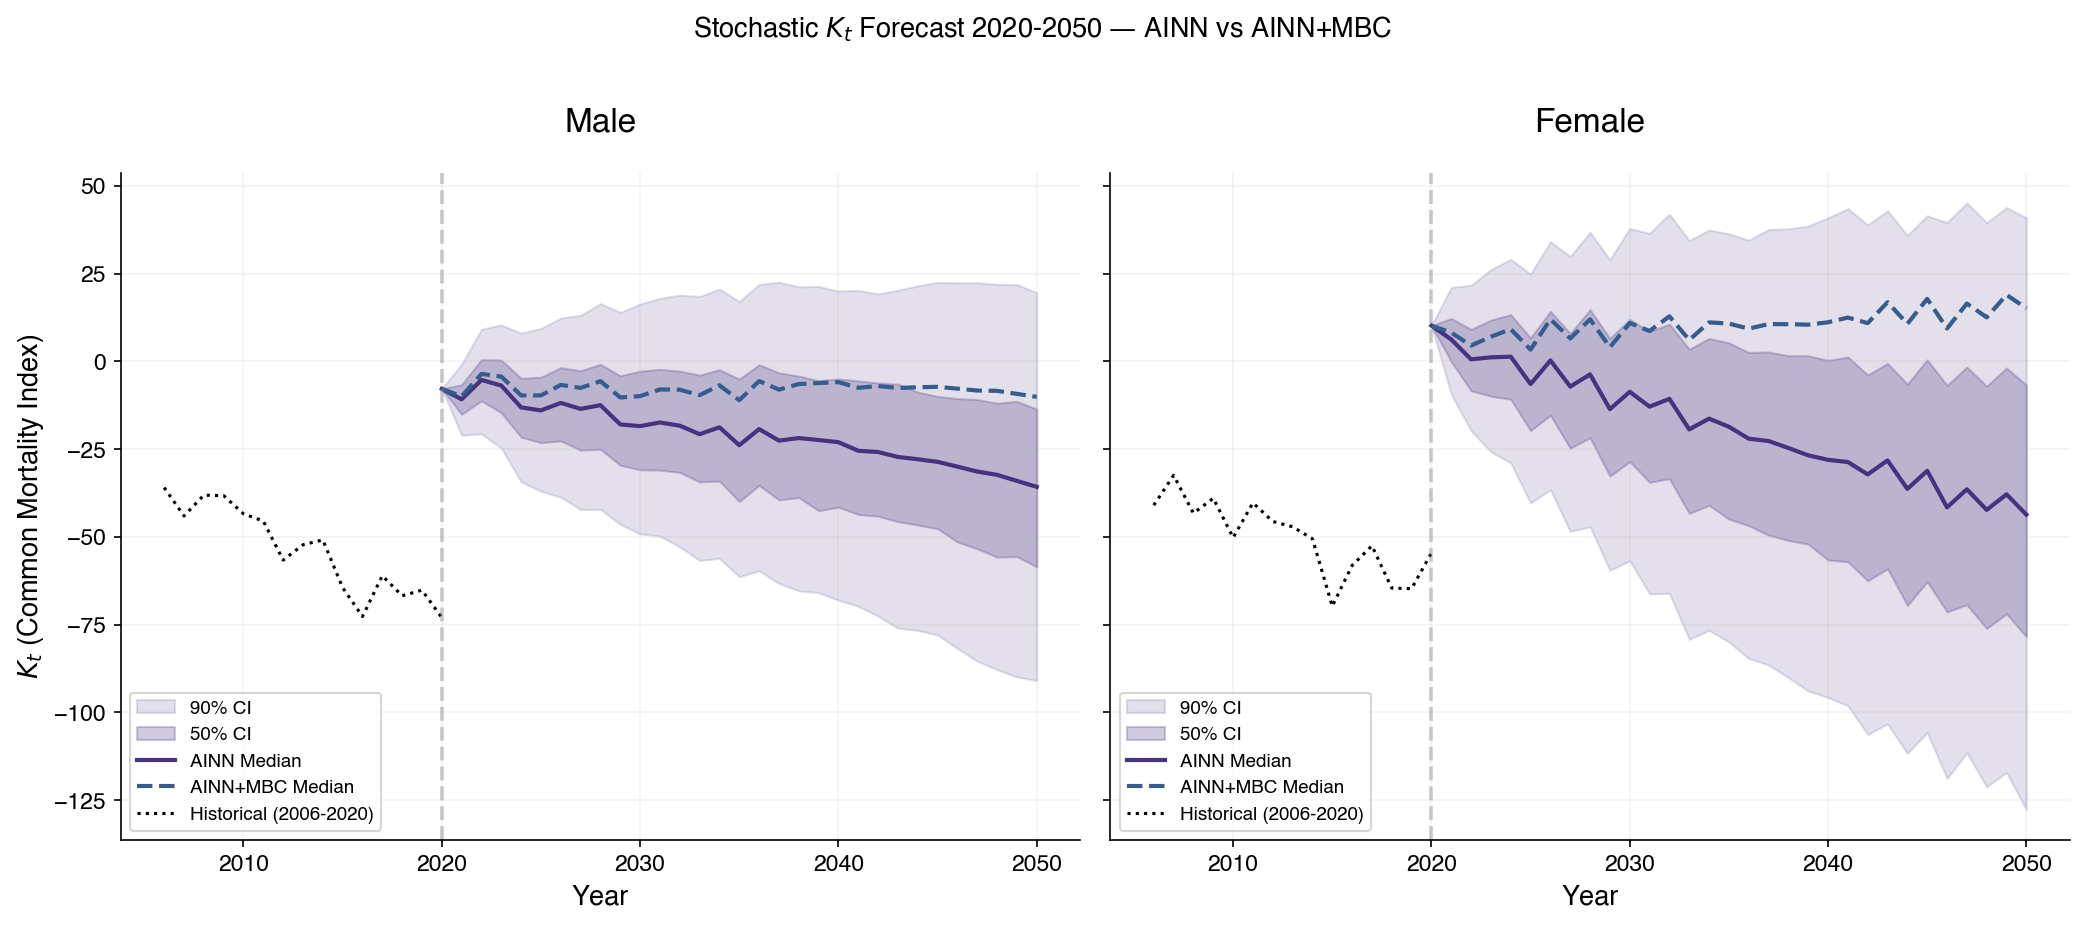

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for sex_idx, (sex, kt_sims, kt_sims_mbc) in enumerate([
    ('Male', kt_male_sims, levels_male_mbc[:, :, 0]),
    ('Female', kt_female_sims, levels_female_mbc[:, :, 0])
]):
    ax = axes[sex_idx]
    
    # Percentiles
    p5  = np.percentile(kt_sims, 5, axis=0)
    p25 = np.percentile(kt_sims, 25, axis=0)
    p50 = np.percentile(kt_sims, 50, axis=0)
    p75 = np.percentile(kt_sims, 75, axis=0)
    p95 = np.percentile(kt_sims, 95, axis=0)
    
    p50_mbc = np.percentile(kt_sims_mbc, 50, axis=0)
    
    ax.fill_between(forecast_years, p5, p95, alpha=0.15, color=COUNTRY_COLORS['CHE'], label='90% CI')
    ax.fill_between(forecast_years, p25, p75, alpha=0.25, color=COUNTRY_COLORS['CHE'], label='50% CI')
    ax.plot(forecast_years, p50, color=COUNTRY_COLORS['CHE'], linewidth=2, label='AINN Median')
    ax.plot(forecast_years, p50_mbc, color=COUNTRY_COLORS['SWE'], linewidth=2,
            linestyle='--', label='AINN+MBC Median')
    
    # Historical reference
    kt_hist = common_factors[sex.lower()]['Kt']
    ax.plot(YEARS[-15:], kt_hist[-15:], color='black', linewidth=1.5,
            linestyle=':', label='Historical (2006-2020)')
    
    ax.axvline(x=YEARS[-1], color='grey', linestyle='--', alpha=0.4)
    ax.set_xlabel("Year")
    ax.set_title(sex)
    if sex_idx == 0:
        ax.set_ylabel("$K_t$ (Common Mortality Index)")
    ax.legend(loc='lower left', framealpha=0.8, fontsize=9)

fig.suptitle("Stochastic $K_t$ Forecast 2020-2050 — AINN vs AINN+MBC", fontsize=13, y=1.02)
plt.tight_layout()
save_dual(fig, "fig10_kt_fan_chart_sex")
plt.show()


## 4.8: Life Expectancy Reconstruction ($e_0$)

Back-transform $K_t$ trajectories into mortality surfaces and compute life expectancy at birth for each country × sex.

In [8]:
def calculate_e0(log_mx):
    """
    Exact actuarial life table: e0 from log-mortality rates.
    - qx = 1 - exp(-mx)  (exact)
    - e0 via trapezoidal rule with l_{omega+1} = 0
    """
    mx = np.exp(log_mx)
    qx = 1.0 - np.exp(-mx)
    qx[-1] = 1.0
    px = 1.0 - qx
    lx = np.concatenate(([1.0], np.cumprod(px[:-1])))
    lx_extended = np.append(lx, 0.0)
    e0 = np.sum((lx_extended[:-1] + lx_extended[1:]) / 2.0)
    return e0


def reconstruct_e0_anchored(sims_diffs_orig, sex):
    """
    Observation-Anchored Life Expectancy Reconstruction.
    
    Starts from OBSERVED mortality at 2020 and applies the cumulative
    variation in the common factor predicted by the model.
    
    Formula (exact):
        ln(m_{x,t,i}) = ln(m_{x,2020,i})^{observed} + B_x * cumsum(delta_Kt)
    
    Args:
        sims_diffs_orig: (n_sims, n_steps, n_features) — first differences
                         in ORIGINAL scale (after inverse transform + noise).
        sex: 'male' or 'female'
    
    Returns:
        e0_all: (n_sims, n_steps+1, n_countries) — e0 trajectories including 2020.
    """
    Bx = common_factors[sex]['Bx']  # shape: (n_ages,)
    
    n_sims = sims_diffs_orig.shape[0]
    n_steps = sims_diffs_orig.shape[1]
    n_countries = len(COUNTRIES)
    
    # Cumulative sum of delta_Kt (column 0) to get the total change from 2020
    # cumulative_delta_kt[s, t] = sum of delta_Kt from step 1 to step t
    delta_kt_all = sims_diffs_orig[:, :, 0]  # (n_sims, n_steps)
    cumulative_delta_kt = np.cumsum(delta_kt_all, axis=1)  # (n_sims, n_steps)
    
    # Prepend zero for 2020 (no change at t=0)
    zeros = np.zeros((n_sims, 1))
    cumulative_delta_kt = np.concatenate([zeros, cumulative_delta_kt], axis=1)  # (n_sims, n_steps+1)
    
    e0_all = np.zeros((n_sims, n_steps + 1, n_countries))
    
    for c_idx, code in enumerate(COUNTRIES.keys()):
        # Load observed log-mortality at 2020
        log_mx_matrix = np.load(os.path.join(PROCESSED_DIR, f"{code}_log_mx_{sex}.npy"))
        log_mx_2020 = log_mx_matrix[:, -1]  # shape: (n_ages,)
        
        for s in range(n_sims):
            for t in range(n_steps + 1):
                # Apply cumulative variation to observed mortality
                log_mx_t = log_mx_2020 + Bx * cumulative_delta_kt[s, t]
                e0_all[s, t, c_idx] = calculate_e0(log_mx_t)
    
    return e0_all


print("Reconstructing e0 (Observation-Anchored, corrected)...")
print("  Male, without MBC...")
e0_male = reconstruct_e0_anchored(sims_male_orig, 'male')

print("  Male, with MBC...")
e0_male_mbc = reconstruct_e0_anchored(sims_male_mbc, 'male')

print("  Female, without MBC...")
e0_female = reconstruct_e0_anchored(sims_female_orig, 'female')

print("  Female, with MBC...")
e0_female_mbc = reconstruct_e0_anchored(sims_female_mbc, 'female')

print(f"\ne0 arrays: {e0_male.shape} — (sims, years+1, countries)")

# Sanity check
che_idx = list(COUNTRIES.keys()).index('CHE')
print(f"\nSanity check (CHE, 2020 — should be ~80 M, ~83 F):")
print(f"  Male e0:   {e0_male[:, 0, che_idx].mean():.2f}")
print(f"  Female e0: {e0_female[:, 0, che_idx].mean():.2f}")


Reconstructing e0 (Observation-Anchored, corrected)...
  Male, without MBC...
  Male, with MBC...
  Female, without MBC...
  Female, with MBC...

e0 arrays: (1000, 31, 6) — (sims, years+1, countries)

Sanity check (CHE, 2020 — should be ~80 M, ~83 F):
  Male e0:   80.26
  Female e0: 83.58


## 4.9: Stochastic Life Expectancy Results (2020-2050)

Summary table of projected $e_0$ medians and 95% confidence intervals for 2050, with and without MBC.

In [9]:
country_list = list(COUNTRIES.keys())
country_names = list(COUNTRIES.values())

results_table = []
for c_idx, (code, name) in enumerate(COUNTRIES.items()):
    for sex, e0_arr, e0_mbc_arr in [('Male', e0_male, e0_male_mbc),
                                      ('Female', e0_female, e0_female_mbc)]:
        e0_2020 = e0_arr[:, 0, c_idx].mean()
        e0_2050_median = np.percentile(e0_arr[:, -1, c_idx], 50)
        e0_2050_p5 = np.percentile(e0_arr[:, -1, c_idx], 5)
        e0_2050_p95 = np.percentile(e0_arr[:, -1, c_idx], 95)
        
        e0_2050_mbc = np.percentile(e0_mbc_arr[:, -1, c_idx], 50)
        
        results_table.append({
            "Country": name, "Sex": sex,
            "e0 (2020)": round(e0_2020, 2),
            "e0 (2050) Median": round(e0_2050_median, 2),
            "95% CI (2050)": f"[{e0_2050_p5:.2f}, {e0_2050_p95:.2f}]",
            "e0 (2050) +MBC": round(e0_2050_mbc, 2),
            "Net Gain": round(e0_2050_median - e0_2020, 2),
        })

df_results = pd.DataFrame(results_table)
print("Stochastic Life Expectancy Projections (2020-2050):")
print("=" * 90)
print(df_results.to_string(index=False))


Stochastic Life Expectancy Projections (2020-2050):
     Country    Sex  e0 (2020)  e0 (2050) Median  95% CI (2050)  e0 (2050) +MBC  Net Gain
 Switzerland   Male      80.26             82.01 [78.21, 84.65]           80.42      1.74
 Switzerland Female      83.58             86.04 [81.66, 88.31]           83.30      2.46
      Sweden   Male      79.94             81.69 [77.91, 84.39]           80.09      1.75
      Sweden Female      82.93             85.55 [80.96, 88.04]           82.64      2.62
      Norway   Male      80.57             82.25 [78.63, 84.82]           80.72      1.68
      Norway Female      83.27             85.79 [81.36, 88.17]           82.98      2.52
West Germany   Male      78.28             80.28 [76.00, 83.41]           78.46      2.00
West Germany Female      82.20             85.06 [80.05, 87.78]           81.88      2.86
 Netherlands   Male      79.14             80.99 [77.00, 83.86]           79.30      1.85
 Netherlands Female      81.96             84.89

## 4.10: Life Expectancy Convergence Plot

Multi-country trajectories showing median $e_0$ 2020-2050 by sex.

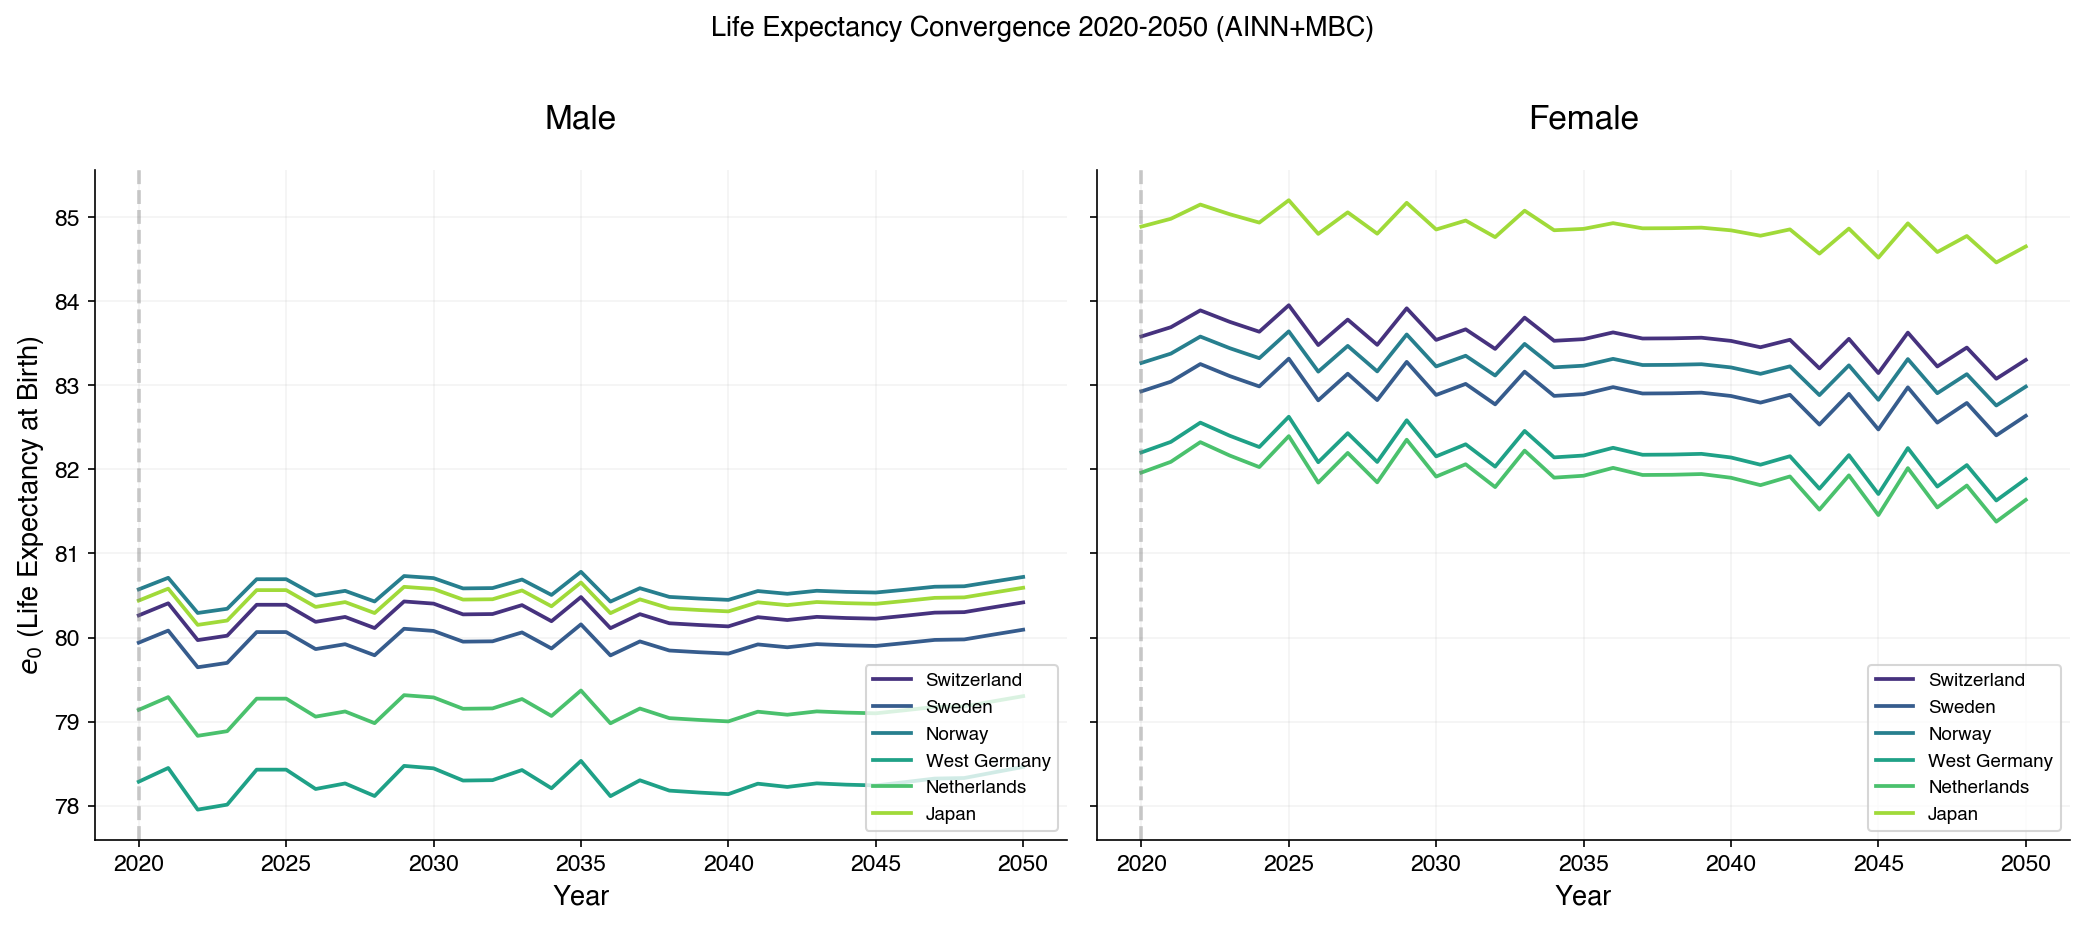

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for sex_idx, (sex, e0_arr) in enumerate([('Male', e0_male_mbc), ('Female', e0_female_mbc)]):
    ax = axes[sex_idx]
    for c_idx, (code, name) in enumerate(COUNTRIES.items()):
        median_traj = np.percentile(e0_arr[:, :, c_idx], 50, axis=0)
        ax.plot(forecast_years, median_traj, color=COUNTRY_COLORS[code],
                label=name, linewidth=1.8)
    
    ax.axvline(x=YEARS[-1], color='grey', linestyle='--', alpha=0.4)
    ax.set_xlabel("Year")
    ax.set_title(sex)
    if sex_idx == 0:
        ax.set_ylabel("$e_0$ (Life Expectancy at Birth)")
    ax.legend(loc='lower right', framealpha=0.8, fontsize=9)

fig.suptitle("Life Expectancy Convergence 2020-2050 (AINN+MBC)", fontsize=13, y=1.02)
plt.tight_layout()
save_dual(fig, "fig11_e0_convergence_sex")
plt.show()


## 4.11: MBC Impact (Switzerland Case Study)

Quantify the effect of MBC on Swiss life expectancy projections (Male and Female).

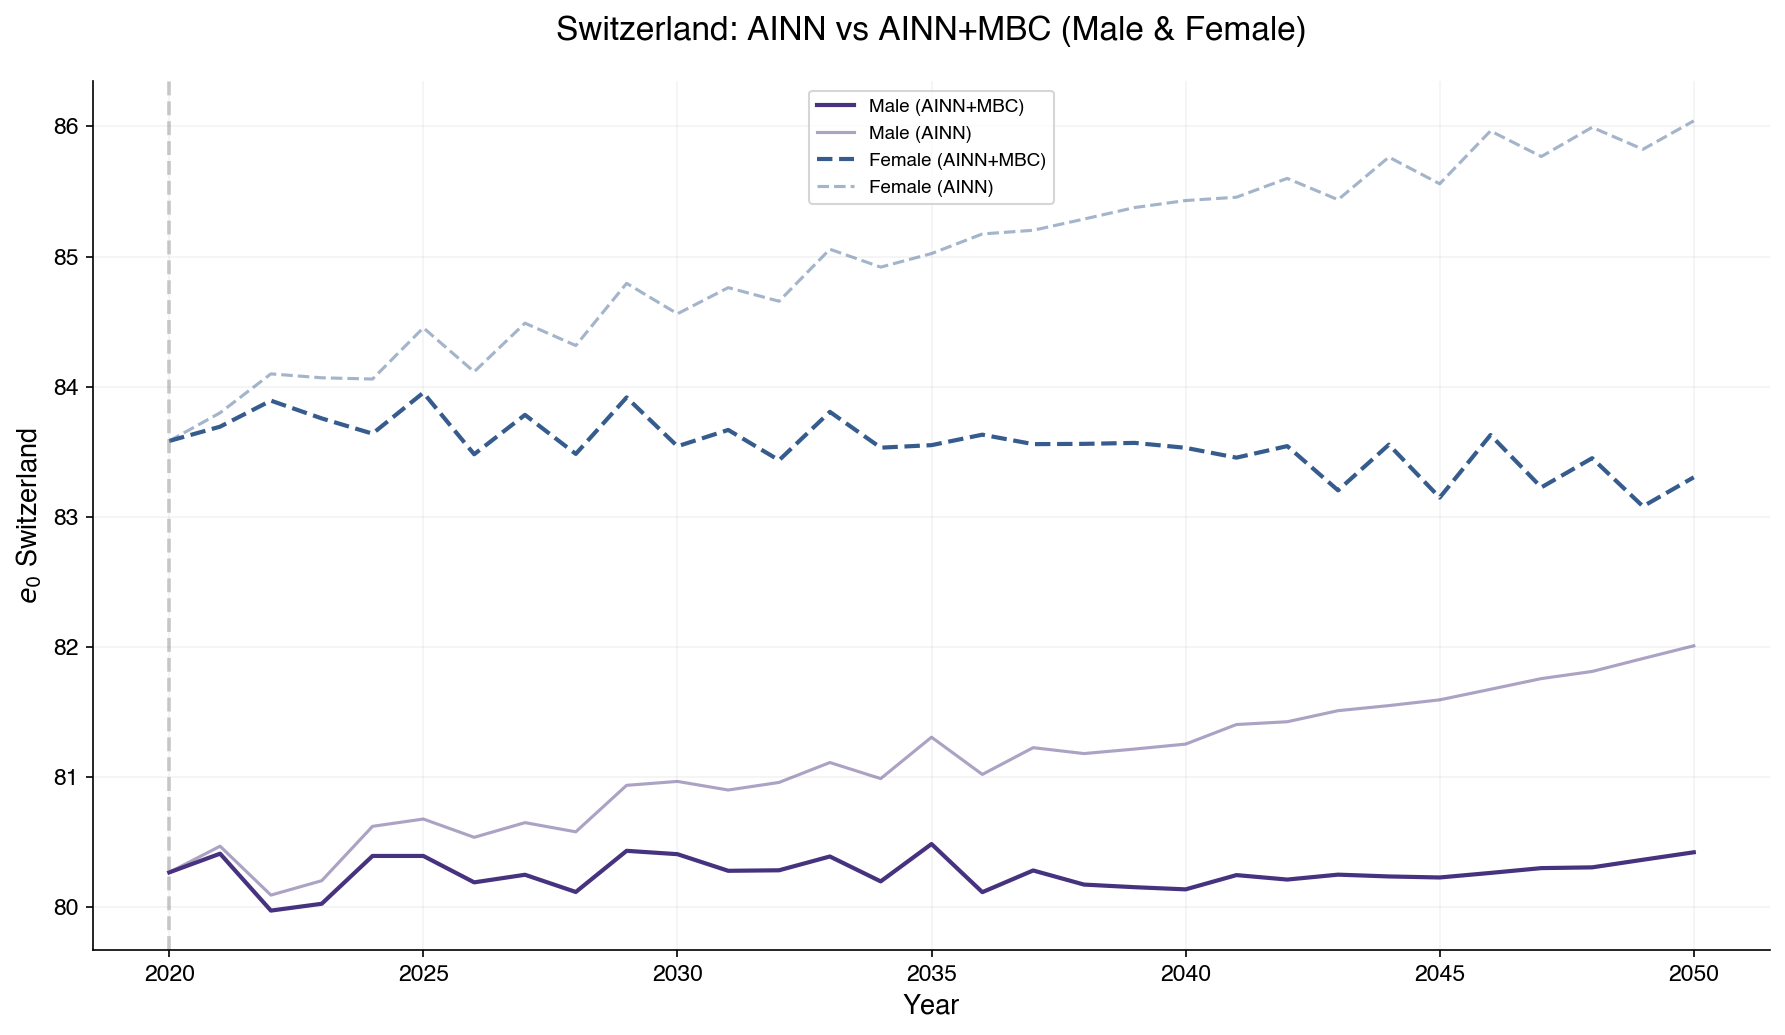

In [11]:
fig, ax = plt.subplots()

che_idx = list(COUNTRIES.keys()).index('CHE')

for sex, e0_raw, e0_mbc, col, ls in [
    ('Male', e0_male[:, :, che_idx], e0_male_mbc[:, :, che_idx], COUNTRY_COLORS['CHE'], '-'),
    ('Female', e0_female[:, :, che_idx], e0_female_mbc[:, :, che_idx], COUNTRY_COLORS['SWE'], '--')
]:
    raw_med = np.percentile(e0_raw, 50, axis=0)
    mbc_med = np.percentile(e0_mbc, 50, axis=0)
    
    ax.plot(forecast_years, mbc_med, color=col, linewidth=2, linestyle=ls,
            label=f'{sex} (AINN+MBC)')
    ax.plot(forecast_years, raw_med, color=col, linewidth=1.5, linestyle=ls,
            alpha=0.45, label=f'{sex} (AINN)')

ax.axvline(x=YEARS[-1], color='grey', linestyle='--', alpha=0.4)
ax.set_xlabel("Year")
ax.set_ylabel("$e_0$ Switzerland")
ax.set_title("Switzerland: AINN vs AINN+MBC (Male & Female)")
ax.legend(fontsize=9)
plt.tight_layout()
save_dual(fig, "fig12_che_mbc_impact")
plt.show()


## 4.12: Persistence

Save all stochastic forecasting results for Notebook 05 (XAI, validation, SCR).

In [12]:
forecasting_assets = {
    # Kt level trajectories
    "kt_male_sims": kt_male_sims,
    "kt_female_sims": kt_female_sims,
    "kt_male_mbc": levels_male_mbc[:, :, 0],
    "kt_female_mbc": levels_female_mbc[:, :, 0],
    
    # e0 trajectories
    "e0_male": e0_male,
    "e0_female": e0_female,
    "e0_male_mbc": e0_male_mbc,
    "e0_female_mbc": e0_female_mbc,
    
    # Metadata
    "forecast_years": forecast_years,
    "n_sims": N_SIMULATIONS,
    "n_years_ahead": N_YEARS_AHEAD,
    "bias_male": bias_male,
    "bias_female": bias_female,
    "process_std_male": noise_std_male,
    "process_std_female": noise_std_female,
    "countries": list(COUNTRIES.keys()),
}

with open(os.path.join(PROCESSED_DIR, "forecasting_assets.pkl"), "wb") as f:
    pickle.dump(forecasting_assets, f)

# Save results table
df_results.to_csv(os.path.join(PROCESSED_DIR, "e0_projections_summary.csv"), index=False)

print("Forecasting assets saved:")
print(f"  {PROCESSED_DIR}forecasting_assets.pkl")
print(f"  {PROCESSED_DIR}e0_projections_summary.csv")
print(f"\nNotebook 04 complete. Proceed to Notebook 05 (XAI, Validation & SCR).")


Forecasting assets saved:
  ../data/processed/forecasting_assets.pkl
  ../data/processed/e0_projections_summary.csv

Notebook 04 complete. Proceed to Notebook 05 (XAI, Validation & SCR).
